# Cats vs Dogs — Binary Image Classification using CNN

## Problem Statement
Build a CNN model to classify images as **cat** or **dog** using the Dogs vs Cats dataset.

## Project Pipeline


## Detailed Problem Statement
Image classification is one of the most widely studied problems in computer
vision. One common benchmark problem is distinguishing between images of
cats and dogs, which requires the model to learn complex visual patterns such
as shapes, textures, and edges.

The goal of this project is to develop a to
perform binary image classification using the . The
dataset contains thousands of labeled images of cats and dogs with varying
backgrounds, lighting conditions, and poses.

# Convolutional Neural Network (CNN)

Dogs vs Cats dataset
The CNN model will automatically learn relevant visual features from raw images
and classify each image into one of two categories: .cat or dog
The project includes dataset preprocessing, CNN model design, training and
validation, and evaluation using metrics such as accuracy, precision, recall,
and confusion matrix

# Expected Outcome

A trained CNN model capable of accurately distinguishing between cats and
dogs, typically achieving 80–95% accuracy depending on architecture and
preprocessing technique

**Author:** Md Adnan | 300 Days of AI-ML Challenge | Deep Learning Phase  
**Dataset:** Dogs vs Cats (Kaggle Competition)  
**Framework:** PyTorch

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla T4


In [3]:
# Check dataset structure
base_path = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset'
print("Files in dataset:")
for f in os.listdir(base_path):
    print(f)

Files in dataset:
PetImages
readme[1].txt
MSR-LA - 3467.docx


In [4]:
# let's see what's inside PetImages
pet_path = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages'

for folder in os.listdir(pet_path):
    folder_path = os.path.join(pet_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

Dog: 12501 images
Cat: 12501 images


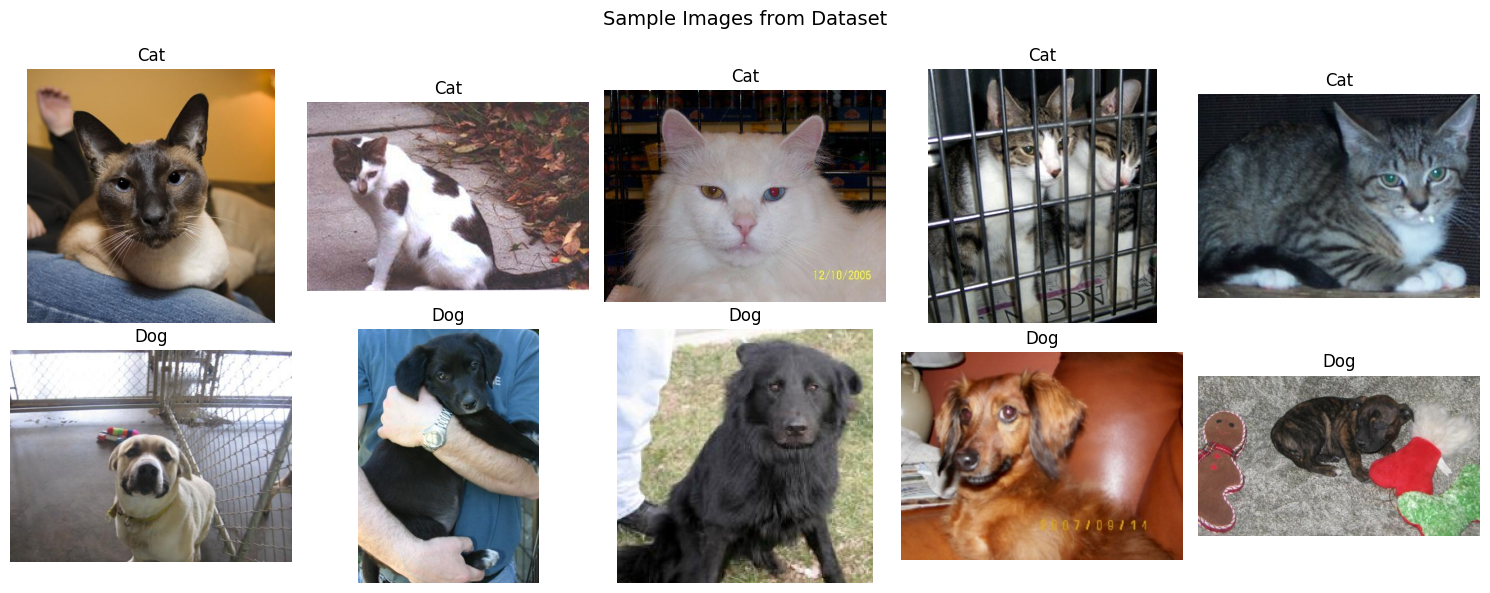

In [5]:
# let's see some sample images from dataset
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=14)

for i, label in enumerate(['Cat', 'Dog']):
    folder = os.path.join(pet_path, label)
    images = random.sample(os.listdir(folder), 5)
    
    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            axes[i][j].imshow(img)
            axes[i][j].set_title(label)
            axes[i][j].axis('off')
        except:
            axes[i][j].axis('off')  # skip corrupted images

plt.tight_layout()
plt.show()

In [6]:
# define transforms for training and validation
# training gets augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# validation just resize and normalize, no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

print("Transforms defined!")

Transforms defined!


In [7]:
class CatsDogsDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        
        # label from folder name — Cat=0, Dog=1
        label = 0 if 'Cat' in img_path else 1
        
        try:
            img = Image.open(img_path).convert('RGB')
        except:
            # some images in dataset are corrupted, skip them
            img = Image.new('RGB', (128, 128))
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

print("Dataset class defined!")

Dataset class defined!


In [8]:
# get all image paths
cat_images = [os.path.join(pet_path, 'Cat', f) 
              for f in os.listdir(os.path.join(pet_path, 'Cat'))]
dog_images = [os.path.join(pet_path, 'Dog', f) 
              for f in os.listdir(os.path.join(pet_path, 'Dog'))]

all_images = cat_images + dog_images
random.shuffle(all_images)

# 80% train, 20% validation
split = int(0.8 * len(all_images))
train_files = all_images[:split]
val_files = all_images[split:]

print(f"Total images: {len(all_images)}")
print(f"Training:     {len(train_files)}")
print(f"Validation:   {len(val_files)}")

# create datasets
train_dataset = CatsDogsDataset(train_files, transform=train_transforms)
val_dataset = CatsDogsDataset(val_files, transform=val_transforms)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Total images: 25002
Training:     20001
Validation:   5001

Train batches: 626
Val batches:   157


## 3. CNN Model Architecture

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # block 1 -- basic edges and colors
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # 128 -> 64
        
        # block 2 -- shapes and textures
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 64 -> 32
        
        # block 3 -- complex features
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 32 -> 16
        
        # batch norm helps training be stable
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        
        # fully connected layers
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, 2)  # 2 classes -- cat or dog
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)  # prevent overfitting
    
    def forward(self, x):
        # block 1
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool1(self.bn1(x))
        
        # block 2
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool2(self.bn2(x))
        
        # block 3
        x = self.relu(self.conv5(x))
        x = self.relu(self.conv6(x))
        x = self.pool3(self.bn3(x))
        
        # flatten and classify
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

model = CNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc

## 4. Training

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam (lr=0.001)")
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


In [11]:
epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(epochs):
    # ---- training phase ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # ---- validation phase ----
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    
    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    # step scheduler
    scheduler.step(val_loss)
    
    # store for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/10] Train Loss: 0.7860 | Train Acc: 61.87% | Val Loss: 0.5994 | Val Acc: 66.81%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/10] Train Loss: 0.5796 | Train Acc: 69.81% | Val Loss: 0.5322 | Val Acc: 72.99%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch [8/10] Train Loss: 0.2656 | Train Acc: 89.13% | Val Loss: 0.2900 | Val Acc: 88.60%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [9/10] Train Loss: 0.2500 | Train Acc: 89.95% | Val Loss: 0.2265 | Val Acc: 90.26%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [10/10] Train Loss: 0.2325 | Train Acc: 90.51% | Val Loss: 0.3132 | Val Acc: 89.44%

Best Validation Accuracy: 90.26%


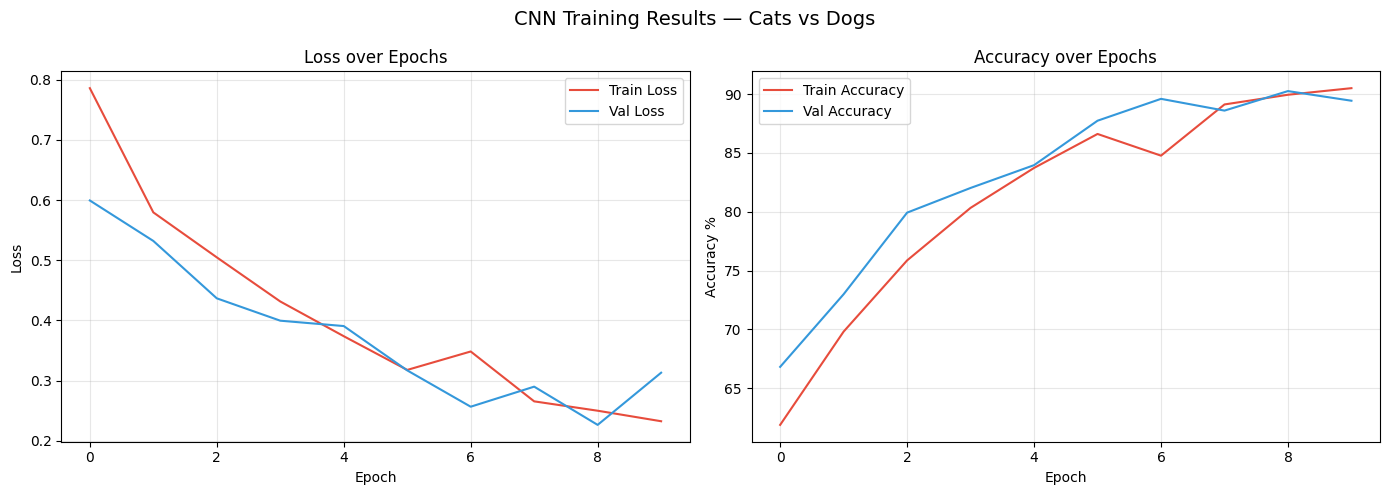

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss plot
ax1.plot(train_losses, label='Train Loss', color='#e74c3c')
ax1.plot(val_losses, label='Val Loss', color='#3498db')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy plot
ax2.plot(train_accs, label='Train Accuracy', color='#e74c3c')
ax2.plot(val_accs, label='Val Accuracy', color='#3498db')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Training Results — Cats vs Dogs', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

## 5. Model Evaluation

In [13]:
# load best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, 
                            target_names=['Cat', 'Dog']))

Classification Report:
              precision    recall  f1-score   support

         Cat       0.93      0.87      0.90      2477
         Dog       0.88      0.94      0.91      2524

    accuracy                           0.90      5001
   macro avg       0.90      0.90      0.90      5001
weighted avg       0.90      0.90      0.90      5001

